In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

df = pd.read_csv('../../../data/cell_classifications.csv')
df = df[df['brain_region'].str.contains('ENTm', na=False)].copy()
df['ml_position'] = np.abs(df['SC_x'])

gcs = df[df['cell_type'] == 'GC'].copy()
ngs = df[df['cell_type'] == 'NG'].copy()

GC_COLOR = '#e05a2b'
NG_COLOR = '#3a86b4'

def bin_mean_sem(x, y, bins):
    x, y = np.array(x, dtype=float), np.array(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    bin_ids = np.digitize(x, bins)
    centres, means, sems = [], [], []
    for i in range(1, len(bins)):
        idx = bin_ids == i
        if idx.sum() < 3:
            continue
        centres.append((bins[i-1] + bins[i]) / 2)
        means.append(np.mean(y[idx]))
        sems.append(stats.sem(y[idx]))
    return np.array(centres), np.array(means), np.array(sems)

def fit_lmm(data, score_col, log_scale):
    """Hierarchical LMM: score ~ ml_position.
    Random structure: random intercept per mouse (level 1),
    variance component for day nested within mouse (level 2).
    cluster_id is the observation level (residual).
    Returns (slope, se, intercept, p_value) on the fitting scale.
    """
    d = data[['ml_position', score_col, 'mouse', 'day']].dropna().copy()
    d['_y'] = np.log10(d[score_col]) if log_scale else d[score_col]
    d = d[np.isfinite(d['_y'])]
    if len(d) < 10:
        return None
    d['mouse_day'] = 'M' + d['mouse'].astype(str) + '_D' + d['day'].astype(str)
    result = smf.mixedlm(
        '_y ~ ml_position',
        data=d,
        groups=d['mouse'],
        vc_formula={'mouse_day': '0 + C(mouse_day)'},
    ).fit(disp=False)
    return (result.params['ml_position'],
            result.bse['ml_position'],
            result.params['Intercept'],
            result.pvalues['ml_position'])

def pval_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

ML_BINS = np.arange(2500, 5500, 250)

print(f'GCs: {len(gcs)}  |  NGs: {len(ngs)}')

GCs: 617  |  NGs: 5182


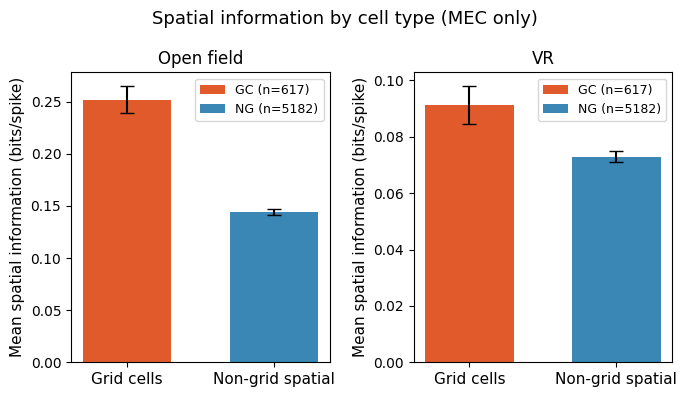

In [35]:
# Bar plots: mean spatial information (OF and VR) for GCs vs NGs
fig, axes = plt.subplots(1, 2, figsize=(7, 4))

for ax, col, title in zip(axes,
                           ['spatial_information_score', 'vr_spatial_information'],
                           ['Open field', 'VR']):
    groups = []
    for subset, label, color in [(gcs, 'GC', GC_COLOR), (ngs, 'NG', NG_COLOR)]:
        vals = subset[col].dropna()
        vals = vals[vals > 0]
        groups.append((label, color, vals.mean(), stats.sem(vals), len(vals)))

    for i, (label, color, mean, sem, n) in enumerate(groups):
        ax.bar(i, mean, yerr=sem, color=color, width=0.6,
               capsize=5, error_kw={'lw': 1.5}, label=f'{label} (n={n})')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Grid cells', 'Non-grid spatial'], fontsize=11)
    ax.set_ylabel('Mean spatial information (bits/spike)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle('Spatial information by cell type (MEC only)', fontsize=13)
plt.tight_layout()
plt.show()

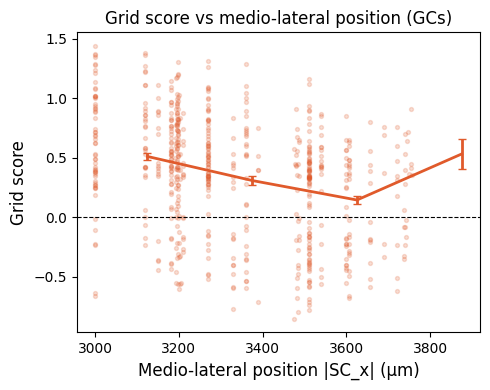

In [36]:
# Grid score vs ML position (GCs only)
fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(gcs['ml_position'], gcs['grid_score'],
           color=GC_COLOR, alpha=0.2, s=8, rasterized=True)

centres, means, sems = bin_mean_sem(gcs['ml_position'], gcs['grid_score'], ML_BINS)
ax.errorbar(centres, means, yerr=sems, color=GC_COLOR, lw=2, capsize=3, zorder=5)

ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Medio-lateral position |SC_x| (µm)', fontsize=12)
ax.set_ylabel('Grid score', fontsize=12)
ax.set_title('Grid score vs medio-lateral position (GCs)', fontsize=12)
plt.tight_layout()
plt.show()

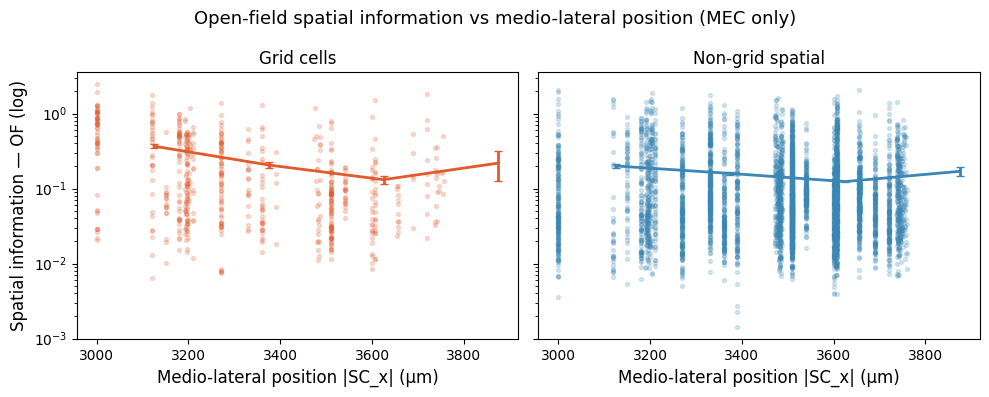

In [37]:
# Open-field spatial information vs ML position (log scale)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, subset, color, label in zip(axes,
                                     [gcs, ngs],
                                     [GC_COLOR, NG_COLOR],
                                     ['Grid cells', 'Non-grid spatial']):
    valid = subset[subset['spatial_information_score'] > 0]
    ax.scatter(valid['ml_position'], valid['spatial_information_score'],
               color=color, alpha=0.2, s=8, rasterized=True)

    centres, means, sems = bin_mean_sem(
        valid['ml_position'], valid['spatial_information_score'], ML_BINS)
    ax.errorbar(centres, means, yerr=sems, color=color, lw=2, capsize=3, zorder=5)

    ax.set_yscale('log')
    ax.set_xlabel('Medio-lateral position |SC_x| (µm)', fontsize=12)
    ax.set_ylabel('Spatial information — OF (log)' if ax is axes[0] else '', fontsize=12)
    ax.set_title(label, fontsize=12)

plt.suptitle('Open-field spatial information vs medio-lateral position (MEC only)', fontsize=13)
plt.tight_layout()
plt.show()

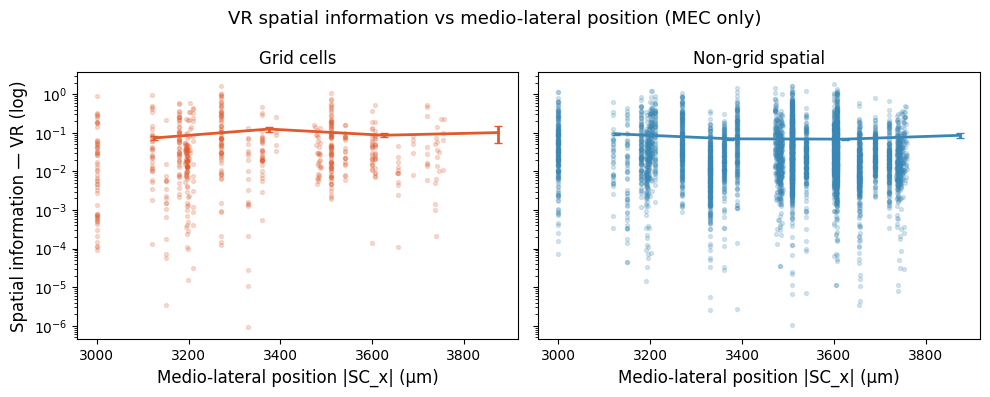

In [38]:
# VR spatial information vs ML position (log scale)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, subset, color, label in zip(axes,
                                     [gcs, ngs],
                                     [GC_COLOR, NG_COLOR],
                                     ['Grid cells', 'Non-grid spatial']):
    valid = subset[subset['vr_spatial_information'].notna() &
                   (subset['vr_spatial_information'] > 0)]
    ax.scatter(valid['ml_position'], valid['vr_spatial_information'],
               color=color, alpha=0.2, s=8, rasterized=True)

    centres, means, sems = bin_mean_sem(
        valid['ml_position'], valid['vr_spatial_information'], ML_BINS)
    ax.errorbar(centres, means, yerr=sems, color=color, lw=2, capsize=3, zorder=5)

    ax.set_yscale('log')
    ax.set_xlabel('Medio-lateral position |SC_x| (µm)', fontsize=12)
    ax.set_ylabel('Spatial information — VR (log)' if ax is axes[0] else '', fontsize=12)
    ax.set_title(label, fontsize=12)

plt.suptitle('VR spatial information vs medio-lateral position (MEC only)', fontsize=13)
plt.tight_layout()
plt.show()

/var/folders/hd/t83f2v6s1vv8wtlhdtp13t4m0000gn/T/ipykernel_94367/831454424.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_box.boxplot(
/var/folders/hd/t83f2v6s1vv8wtlhdtp13t4m0000gn/T/ipykernel_94367/831454424.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_box.boxplot(
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/sm/lib/python3.11/site-pack

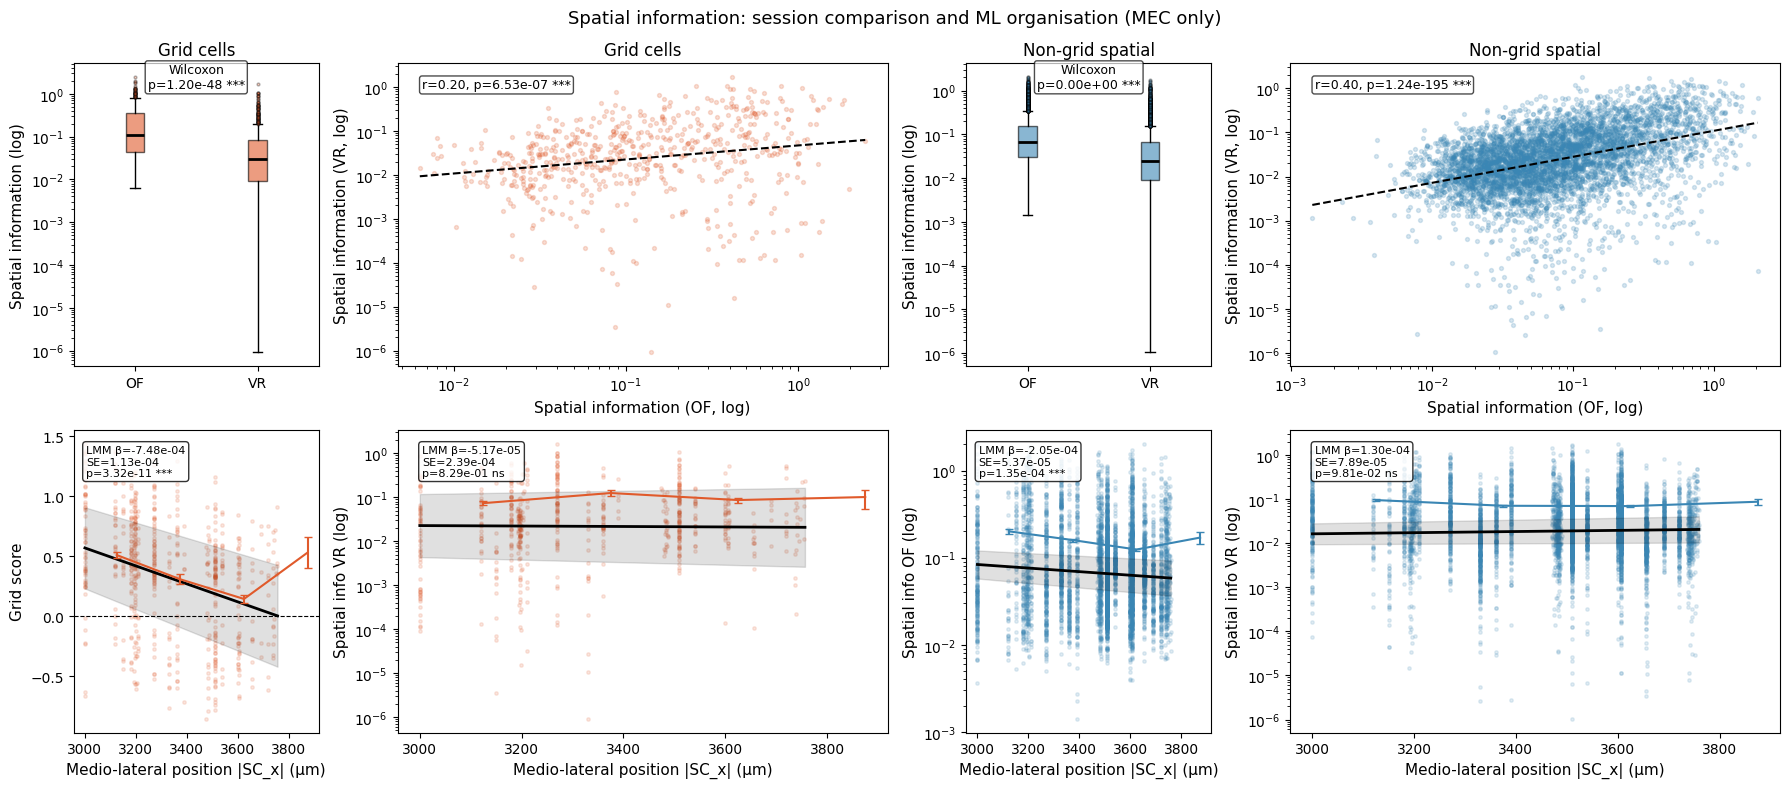

In [39]:
# ── 2-row combined figure ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8),
                         gridspec_kw={'width_ratios': [1, 2, 1, 2]})

# ── Row 1: boxplot + OF vs VR scatter ────────────────────────────────────────
for i, (subset, color, label) in enumerate(zip(
        [gcs, ngs], [GC_COLOR, NG_COLOR], ['Grid cells', 'Non-grid spatial'])):

    ax_box  = axes[0, i * 2]
    ax_scat = axes[0, i * 2 + 1]

    valid = subset[subset['vr_spatial_information'].notna() &
                   subset['spatial_information_score'].notna() &
                   (subset['vr_spatial_information'] > 0) &
                   (subset['spatial_information_score'] > 0)]

    # boxplot
    of_vals = valid['spatial_information_score'].values
    vr_vals = valid['vr_spatial_information'].values
    ax_box.boxplot(
        [of_vals, vr_vals],
        labels=['OF', 'VR'],
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color='k', lw=2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3, markerfacecolor=color),
    )
    ax_box.set_yscale('log')
    ax_box.set_ylabel('Spatial information (log)', fontsize=11)
    ax_box.set_title(label, fontsize=12)

    # Wilcoxon signed-rank annotation
    _, p_wilcox = stats.wilcoxon(of_vals, vr_vals)
    y_top = ax_box.get_ylim()[1]
    ax_box.annotate(f'Wilcoxon\np={p_wilcox:.2e} {pval_stars(p_wilcox)}',
                    xy=(1.5, y_top), xycoords='data',
                    ha='center', va='top', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

    # scatter
    ax_scat.scatter(valid['spatial_information_score'], valid['vr_spatial_information'],
                    color=color, alpha=0.2, s=8, rasterized=True)
    x = np.log10(valid['spatial_information_score'].values)
    y = np.log10(valid['vr_spatial_information'].values)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() > 5:
        slope, intercept, r, p, _ = stats.linregress(x[mask], y[mask])
        xfit = np.linspace(x[mask].min(), x[mask].max(), 100)
        ax_scat.plot(10**xfit, 10**(slope * xfit + intercept), 'k--', lw=1.5)
        ax_scat.annotate(f'r={r:.2f}, p={p:.2e} {pval_stars(p)}',
                         xy=(0.05, 0.95), xycoords='axes fraction',
                         ha='left', va='top', fontsize=9,
                         bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
    ax_scat.set_xscale('log')
    ax_scat.set_yscale('log')
    ax_scat.set_xlabel('Spatial information (OF, log)', fontsize=11)
    ax_scat.set_ylabel('Spatial information (VR, log)', fontsize=11)
    ax_scat.set_title(label, fontsize=12)

# ── Row 2: score vs ML position with hierarchical LMM ────────────────────────
row2_specs = [
    (gcs, GC_COLOR, 'grid_score',                'Grid score',            False),
    (gcs, GC_COLOR, 'vr_spatial_information',    'Spatial info VR (log)', True),
    (ngs, NG_COLOR, 'spatial_information_score', 'Spatial info OF (log)', True),
    (ngs, NG_COLOR, 'vr_spatial_information',    'Spatial info VR (log)', True),
]

for col_idx, (subset, color, score_col, ylabel, log_scale) in enumerate(row2_specs):
    ax = axes[1, col_idx]

    valid = subset[subset[score_col].notna() & subset['ml_position'].notna()]
    if log_scale:
        valid = valid[valid[score_col] > 0]

    ax.scatter(valid['ml_position'], valid[score_col],
               color=color, alpha=0.15, s=6, rasterized=True)

    centres, means, sems = bin_mean_sem(
        valid['ml_position'], valid[score_col], ML_BINS)
    ax.errorbar(centres, means, yerr=sems, color=color, lw=1.5, capsize=3, zorder=5)

    # Hierarchical LMM fit + annotation
    try:
        lmm = fit_lmm(valid, score_col, log_scale)
        if lmm is not None:
            slope, se, intercept, p_lmm = lmm
            x_range = np.linspace(valid['ml_position'].min(),
                                  valid['ml_position'].max(), 200)
            y_fit   = intercept + slope * x_range
            y_upper = intercept + (slope + se) * x_range
            y_lower = intercept + (slope - se) * x_range
            if log_scale:
                ax.plot(x_range, 10**y_fit, 'k-', lw=2)
                ax.fill_between(x_range, 10**y_lower, 10**y_upper,
                                color='k', alpha=0.12)
            else:
                ax.plot(x_range, y_fit, 'k-', lw=2)
                ax.fill_between(x_range, y_lower, y_upper,
                                color='k', alpha=0.12)
            ax.annotate(
                f'LMM β={slope:.2e}\nSE={se:.2e}\np={p_lmm:.2e} {pval_stars(p_lmm)}',
                xy=(0.05, 0.95), xycoords='axes fraction',
                ha='left', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
    except Exception as e:
        print(f'LMM failed for {score_col}: {e}')

    if log_scale:
        ax.set_yscale('log')
    if not log_scale:
        ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Medio-lateral position |SC_x| (µm)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

plt.suptitle('Spatial information: session comparison and ML organisation (MEC only)', fontsize=13)
plt.tight_layout()
plt.show()

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

df = pd.read_csv('../../../data/cell_classifications.csv')
df = df[df['brain_region'].str.contains('ENTm', na=False)].copy()
df['ml_position'] = np.abs(df['SC_x'])
df['depth_layer'] = df['brain_region'].apply(
    lambda r: 'superficial' if r in {'ENTm1', 'ENTm2', 'ENTm3'}
              else ('deep' if r in {'ENTm5', 'ENTm6'} else np.nan)
)

gcs = df[df['cell_type'] == 'GC'].copy()
ngs = df[df['cell_type'] == 'NG'].copy()

GC_COLOR = '#e05a2b'
NG_COLOR = '#3a86b4'

def bin_mean_sem(x, y, bins):
    x, y = np.array(x, dtype=float), np.array(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    bin_ids = np.digitize(x, bins)
    centres, means, sems = [], [], []
    for i in range(1, len(bins)):
        idx = bin_ids == i
        if idx.sum() < 3:
            continue
        centres.append((bins[i-1] + bins[i]) / 2)
        means.append(np.mean(y[idx]))
        sems.append(stats.sem(y[idx]))
    return np.array(centres), np.array(means), np.array(sems)

def fit_lmm(data, score_col, log_scale, depth_covariate=False):
    """Hierarchical LMM: score ~ ml_position [+ depth_layer].
    Random intercept per mouse; variance component for day nested within mouse.
    Returns (slope, se, intercept, p_value) for ml_position.
    """
    cols = ['ml_position', score_col, 'mouse', 'day']
    if depth_covariate:
        cols.append('depth_layer')
    d = data[cols].dropna().copy()
    d['_y'] = np.log10(d[score_col]) if log_scale else d[score_col]
    d = d[np.isfinite(d['_y'])]
    if len(d) < 10:
        return None
    if depth_covariate and d['depth_layer'].nunique() < 2:
        return None
    d['mouse_day'] = 'M' + d['mouse'].astype(str) + '_D' + d['day'].astype(str)
    formula = ("_y ~ ml_position + C(depth_layer, Treatment('superficial'))"
               if depth_covariate else '_y ~ ml_position')
    result = smf.mixedlm(
        formula,
        data=d,
        groups=d['mouse'],
        vc_formula={'mouse_day': '0 + C(mouse_day)'},
    ).fit(disp=False)
    return (result.params['ml_position'],
            result.bse['ml_position'],
            result.params['Intercept'],
            result.pvalues['ml_position'])

def fit_lmm_depth_effect(data, score_col, log_scale):
    """Same model as fit_lmm(depth_covariate=True) but returns the depth term too."""
    cols = ['ml_position', score_col, 'mouse', 'day', 'depth_layer']
    d = data[cols].dropna().copy()
    d['_y'] = np.log10(d[score_col]) if log_scale else d[score_col]
    d = d[np.isfinite(d['_y'])]
    if len(d) < 10 or d['depth_layer'].nunique() < 2:
        return None
    d['mouse_day'] = 'M' + d['mouse'].astype(str) + '_D' + d['day'].astype(str)
    result = smf.mixedlm(
        "_y ~ ml_position + C(depth_layer, Treatment('superficial'))",
        data=d,
        groups=d['mouse'],
        vc_formula={'mouse_day': '0 + C(mouse_day)'},
    ).fit(disp=False)
    depth_key = next((k for k in result.params.index if 'depth_layer' in k and 'deep' in k), None)
    return {
        'ml_slope': result.params['ml_position'],
        'ml_se':    result.bse['ml_position'],
        'ml_p':     result.pvalues['ml_position'],
        'depth_beta': result.params[depth_key] if depth_key else np.nan,
        'depth_p':    result.pvalues[depth_key] if depth_key else np.nan,
    }

def pval_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

ML_BINS = np.arange(2500, 5500, 250)

print(f'GCs: {len(gcs)}  |  NGs: {len(ngs)}')
print(f"Depth breakdown:\n{df.groupby(['cell_type','depth_layer']).size().unstack(fill_value=0)}")


GCs: 617  |  NGs: 5182
Depth breakdown:
depth_layer  deep  superficial
cell_type                     
GC            134          483
NG           1754         3428
Other         922          654


Superficial GCs: 483  |  Superficial NGs: 3428


/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


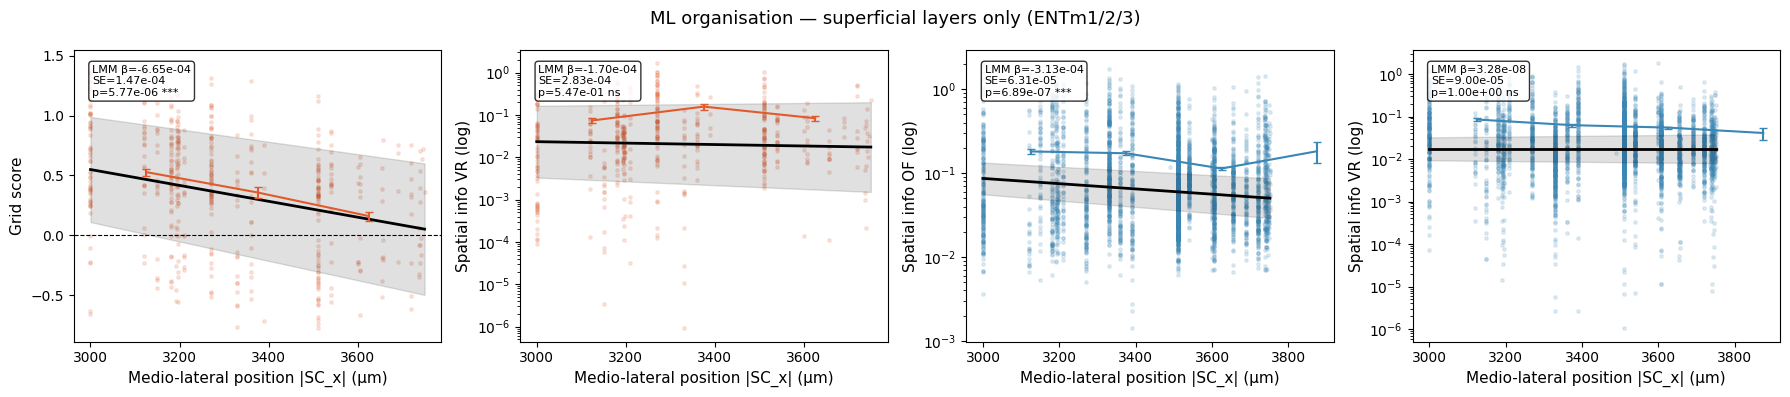

In [41]:
# ── Superficial-only ML organisation (ENTm1/2/3) ──────────────────────────────
gcs_sup = gcs[gcs['depth_layer'] == 'superficial']
ngs_sup = ngs[ngs['depth_layer'] == 'superficial']
print(f'Superficial GCs: {len(gcs_sup)}  |  Superficial NGs: {len(ngs_sup)}')

row2_sup_specs = [
    (gcs_sup, GC_COLOR, 'grid_score',                'Grid score',            False),
    (gcs_sup, GC_COLOR, 'vr_spatial_information',    'Spatial info VR (log)', True),
    (ngs_sup, NG_COLOR, 'spatial_information_score', 'Spatial info OF (log)', True),
    (ngs_sup, NG_COLOR, 'vr_spatial_information',    'Spatial info VR (log)', True),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for col_idx, (subset, color, score_col, ylabel, log_scale) in enumerate(row2_sup_specs):
    ax = axes[col_idx]
    valid = subset[subset[score_col].notna() & subset['ml_position'].notna()]
    if log_scale:
        valid = valid[valid[score_col] > 0]

    ax.scatter(valid['ml_position'], valid[score_col],
               color=color, alpha=0.15, s=6, rasterized=True)

    centres, means, sems = bin_mean_sem(valid['ml_position'], valid[score_col], ML_BINS)
    ax.errorbar(centres, means, yerr=sems, color=color, lw=1.5, capsize=3, zorder=5)

    try:
        lmm = fit_lmm(valid, score_col, log_scale)
        if lmm is not None:
            slope, se, intercept, p_lmm = lmm
            x_range = np.linspace(valid['ml_position'].min(), valid['ml_position'].max(), 200)
            y_fit   = intercept + slope * x_range
            y_upper = intercept + (slope + se) * x_range
            y_lower = intercept + (slope - se) * x_range
            if log_scale:
                ax.plot(x_range, 10**y_fit, 'k-', lw=2)
                ax.fill_between(x_range, 10**y_lower, 10**y_upper, color='k', alpha=0.12)
            else:
                ax.plot(x_range, y_fit, 'k-', lw=2)
                ax.fill_between(x_range, y_lower, y_upper, color='k', alpha=0.12)
            ax.annotate(
                f'LMM β={slope:.2e}\nSE={se:.2e}\np={p_lmm:.2e} {pval_stars(p_lmm)}',
                xy=(0.05, 0.95), xycoords='axes fraction',
                ha='left', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
    except Exception as e:
        print(f'LMM failed for {score_col}: {e}')

    if log_scale:
        ax.set_yscale('log')
    if not log_scale:
        ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Medio-lateral position |SC_x| (µm)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

plt.suptitle('ML organisation — superficial layers only (ENTm1/2/3)', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# ── Does depth confound the ML gradient? LMM comparison table ─────────────────
# Compare ML slope before and after adding depth_layer as a fixed effect.
# If slope shrinks substantially or loses significance, depth is a confound.

row2_specs_labels = [
    (gcs, GC_COLOR, 'grid_score',                'GC grid score',       False),
    (gcs, GC_COLOR, 'vr_spatial_information',    'GC spatial info VR',  True),
    (ngs, NG_COLOR, 'spatial_information_score', 'NG spatial info OF',  True),
    (ngs, NG_COLOR, 'vr_spatial_information',    'NG spatial info VR',  True),
]

hdr = (f"{'Outcome':<22} {'ML β (base)':>12} {'p':>8}  "
       f"{'ML β (+depth)':>14} {'p':>8}  {'depth β (deep)':>15} {'p':>8}")
print(hdr)
print('─' * len(hdr))

for subset, _, score_col, label, log_scale in row2_specs_labels:
    valid = subset[subset[score_col].notna() & subset['ml_position'].notna()]
    if log_scale:
        valid = valid[valid[score_col] > 0]
    try:
        base = fit_lmm(valid, score_col, log_scale)
        dep  = fit_lmm_depth_effect(valid, score_col, log_scale)
        if base and dep:
            print(f"{label:<22} {base[0]:>12.3e} {base[3]:>8.3e}  "
                  f"{dep['ml_slope']:>14.3e} {dep['ml_p']:>8.3e}  "
                  f"{dep['depth_beta']:>15.3e} {dep['depth_p']:>8.3e}")
        else:
            print(f"{label:<22}  insufficient data")
    except Exception as e:
        print(f"{label:<22}  failed: {e}")

print()
print("depth β: log10-scale difference (deep minus superficial) when log_scale=True")


Outcome                 ML β (base)        p   ML β (+depth)        p   depth β (deep)        p
───────────────────────────────────────────────────────────────────────────────────────────────


/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals


GC grid score            -7.476e-04 3.317e-11      -7.097e-04 1.152e-09       -6.957e-02 1.598e-01
GC spatial info VR       -5.166e-05 8.290e-01      -9.676e-05 6.944e-01        6.890e-02 4.381e-01
NG spatial info OF       -2.052e-04 1.347e-04      -2.416e-04 9.217e-06        7.166e-02 3.772e-05
NG spatial info VR        1.305e-04 9.812e-02       5.108e-05 5.205e-01        1.570e-01 1.372e-10

depth β: log10-scale difference (deep minus superficial) when log_scale=True


: 

## Interpreting the depth-covariate LMM comparison table

### Column guide

| Column | Meaning |
|---|---|
| `ML β (base)` | ML slope from the original model: `score ~ ml_position` |
| `p` | p-value for that slope |
| `ML β (+depth)` | ML slope after adding `depth_layer` as a fixed effect |
| `p` | p-value for the depth-controlled slope |
| `depth β (deep)` | Difference in score for deep cells (ENTm5/6) vs superficial (ENTm1/2/3), on the fitting scale |
| `p` | p-value for the depth effect |

For log-scale outcomes, all β values are in **log₁₀ units** (e.g., β = 0.3 ≈ 2× difference).

---

### Reading the three possible outcomes

#### 1. ML slope is robust — depth is not a confound
- `ML β (+depth)` ≈ `ML β (base)` in magnitude and significance
- `depth β` may or may not be significant
- **Interpretation:** the ML gradient exists independently of laminar composition. Report the base model; note depth was tested and did not alter the result.

#### 2. ML slope weakens/disappears after adding depth
- `ML β (+depth)` shrinks substantially or loses significance
- `depth β` is large and significant
- **Interpretation:** the apparent ML gradient is partly or wholly driven by a laminar confound (e.g., deep cells are over-represented medially or laterally). **Primary result should shift to the superficial-only plots.** The base model overstates the ML effect.

#### 3. ML slope strengthens after adding depth
- `ML β (+depth)` is larger than `ML β (base)`
- `depth β` is in the opposite direction to the ML gradient
- **Interpretation:** deep cells were suppressing the ML signal (Simpson's paradox-like). The true within-layer gradient is stronger than the raw data suggest.

---

### Assessing the depth effect itself

`depth β` is log₁₀(deep) − log₁₀(superficial) for log-scale outcomes:

| `depth β` | Approximate fold-difference |
|---|---|
| 0.1 | ~1.3× |
| 0.3 | ~2× |
| 0.5 | ~3× |
| 1.0 | 10× |

A significant negative `depth β` means deep cells have lower spatial information — consistent with the known biology (layer 2 stellate cells, where grid cells concentrate, have higher spatial specificity than deep pyramidal cells).

---

### Cross-checking with superficial-only plots

The superficial-only figure is a non-parametric sanity check. If:
- the binned mean ± SEM trend matches the full-data trend → depth is not driving the result
- the trend flattens or reverses in superficial-only → the ML gradient was a depth artefact

Both checks (covariate model + superficial-only plot) should agree. If they disagree, inspect the ML distribution of deep vs superficial cells with a histogram before concluding.
